# ETAPE 5 — Création de nouvelles variables (Feature Engineering)
**Projet : Optimisation du Réseau de Boutiques TELECOM — Groupe 5 SUD-EST**

---
### Variables à créer
| Variable | Description |
|---|---|
| `age_client` | Âge approx. du client à l'achat |
| `tranche_age` | Catégorie d'âge (18-25, 26-40, 41-60, 60+) |
| `annee` / `trimestre` | Extraction temporelle |
| `distance_km` | Distance Haversine client ↔ boutique |
| `rayon_chalandise` | Bucket de distance (<5, 5-20, 20-50, >50 km) |
| `croissance_yoy` | Taux de croissance annuel par boutique |
| `part_mobile` / `part_fixe` | Spécialisation boutique |
| `score_rentabilite` | CA estimé / Coût de fonctionnement |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130})

df = pd.read_csv('base_travail_SUD_EST.csv', low_memory=False, parse_dates=['PERIOD'])
print(f"Dataset : {len(df):,} lignes x {df.shape[1]} colonnes")

Dataset : 226,677 lignes x 21 colonnes


## 5.1 Variables temporelles

In [2]:
df['annee']     = df['PERIOD_YYYY']
df['trimestre'] = df['PERIOD_MM'].apply(lambda m: f"Q{(m-1)//3+1}")

print("Trimestres :")
print(df['trimestre'].value_counts().sort_index())

Trimestres :
trimestre
Q4    226677
Name: count, dtype: int64


## 5.2 Âge client & Tranche d'âge

In [3]:
def parse_decade(val):
    try:
        return int(str(val).split('-')[0])
    except:
        return np.nan

df['birth_decade'] = df['PERSON_BIRTH_DT_year'].apply(parse_decade)
ANNEE_REF = 2024
df['age_client'] = ANNEE_REF - (df['birth_decade'] + 5)

df['tranche_age'] = pd.cut(
    df['age_client'],
    bins=[0, 25, 40, 60, 120],
    labels=['18-25', '26-40', '41-60', '60+']
)

print(f"Âge moyen : {df['age_client'].mean():.1f} ans")
print("\nRépartition tranches d'âge :")
print(df['tranche_age'].value_counts().sort_index())

Âge moyen : 50.4 ans

Répartition tranches d'âge :
tranche_age
18-25     6304
26-40    77587
41-60    82083
60+      47967
Name: count, dtype: int64


## 5.3 Distance client ↔ boutique (Haversine)

> **Méthode** : La boutique a des coordonnées GPS (latitude/longitude).  
> Le client a une ville (`CITY_LN`). On utilise une table de référence des villes françaises pour obtenir les coordonnées GPS de la ville client, puis on calcule la distance Haversine.
>
> **Note** : Pour les villes non trouvées dans la table de référence, distance = NaN.

In [4]:
# Table des villes françaises — villes clés SUD-EST + communes fréquentes
# Source : données publiques INSEE / OpenData
VILLES_FR = {
    # Grandes villes SUD-EST
    'MARSEILLE': (43.296, 5.370), 'NICE': (43.710, 7.262),
    'TOULON': (43.124, 5.928), 'MONTPELLIER': (43.611, 3.876),
    'AVIGNON': (43.949, 4.806), 'NIMES': (43.837, 4.360),
    'AIX EN PROVENCE': (43.530, 5.447), 'AIX-EN-PROVENCE': (43.530, 5.447),
    'PERPIGNAN': (42.698, 2.895), 'ARLES': (43.676, 4.628),
    'CANNES': (43.553, 7.017), 'ANTIBES': (43.581, 7.128),
    'NARBONNE': (43.185, 3.003), 'BEZIERS': (43.345, 3.220),
    'VALENCE': (44.933, 4.892), 'GRENOBLE': (45.188, 5.724),
    'LYON': (45.764, 4.836), 'ORANGE': (44.137, 4.808),
    'SALON DE PROVENCE': (43.642, 5.098), 'MARTIGUES': (43.406, 5.048),
    'FOS SUR MER': (43.434, 4.943), 'ISTRES': (43.515, 4.988),
    'AUBAGNE': (43.293, 5.572), 'LA CIOTAT': (43.174, 5.608),
    'HYERES': (43.120, 6.128), 'LA SEYNE SUR MER': (43.101, 5.882),
    'DRAGUIGNAN': (43.537, 6.465), 'FREJUS': (43.433, 6.737),
    'SAINT RAPHAEL': (43.425, 6.769), 'GRASSE': (43.658, 6.924),
    'CAGNES SUR MER': (43.664, 7.149), 'MENTON': (43.775, 7.497),
    'MONACO': (43.737, 7.424), 'VILLEFRANCHE SUR MER': (43.704, 7.307),
    'BAGNOLS SUR CEZE': (44.160, 4.622), 'ALES': (44.128, 4.082),
    'LUNEL': (43.676, 4.133), 'SETE': (43.406, 3.697),
    'PALAVAS LES FLOTS': (43.530, 3.929), 'AGDE': (43.309, 3.476),
    'MILLAU': (44.099, 3.078), 'ALBI': (43.930, 2.148),
    'NANTERRE': (48.892, 2.206),  # IDF (quelques clients hors zone)
    'PARIS': (48.857, 2.347), 'BORDEAUX': (44.838, -0.579),
    'TOULOUSE': (43.605, 1.444), 'STRASBOURG': (48.584, 7.750),
    'LAVAL PRADEL': (44.340, 4.100),  # présent dans les données
    'MAROLLES SUR SEINE': (48.384, 3.049),
}

def haversine(lat1, lon1, lat2, lon2):
    """Distance en km entre deux points GPS."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Précalculer les coords GPS par ville unique pour éviter N appels
villes_uniques = df['CITY_LN'].str.strip().str.upper().unique()
ville_to_coords = {v: VILLES_FR.get(v) for v in villes_uniques}
taux_couverture = sum(1 for v in ville_to_coords.values() if v is not None) / len(ville_to_coords) * 100
print(f"Villes uniques dans le dataset : {len(villes_uniques):,}")
print(f"Villes trouvées dans la table de référence : {sum(1 for v in ville_to_coords.values() if v is not None)}")
print(f"Taux de couverture : {taux_couverture:.1f}%")

Villes uniques dans le dataset : 1,779
Villes trouvées dans la table de référence : 25
Taux de couverture : 1.4%


In [5]:
# Paires uniques boutique × ville
pairs = df[['ORDER_SHOP_CD', 'CITY_LN', 'latitude', 'longitude']].drop_duplicates(
    subset=['ORDER_SHOP_CD', 'CITY_LN']
).copy()

# Lookup coords ville client (vectorisé)
city_upper = pairs['CITY_LN'].str.strip().str.upper()
pairs['client_lat'] = city_upper.map(lambda v: VILLES_FR.get(v, (np.nan, np.nan))[0])
pairs['client_lon'] = city_upper.map(lambda v: VILLES_FR.get(v, (np.nan, np.nan))[1])

# Haversine vectorisé avec NumPy
lat1 = np.radians(pairs['latitude'].values)
lon1 = np.radians(pairs['longitude'].values)
lat2 = np.radians(pairs['client_lat'].values)
lon2 = np.radians(pairs['client_lon'].values)

dlat = lat2 - lat1
dlon = lon2 - lon1
a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
pairs['distance_km'] = 6371 * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Joindre au dataset principal (drop si déjà présent pour re-run)
df = df.drop(columns=['distance_km'], errors='ignore')
df = df.merge(
    pairs[['ORDER_SHOP_CD', 'CITY_LN', 'distance_km']],
    on=['ORDER_SHOP_CD', 'CITY_LN'],
    how='left'
)

n_ok = df['distance_km'].notna().sum()
print(f"\nDistances calculées : {n_ok:,} / {len(df):,} lignes ({n_ok/len(df)*100:.1f}%)")
print(f"\nStats distance_km :")
print(df['distance_km'].describe().round(1))


Distances calculées : 26,835 / 226,677 lignes (11.8%)

Stats distance_km :
count    26835.0
mean        36.6
std        129.4
min          0.0
25%          0.8
50%          3.6
75%          8.0
max       1054.9
Name: distance_km, dtype: float64


## 5.4 Rayon de chalandise

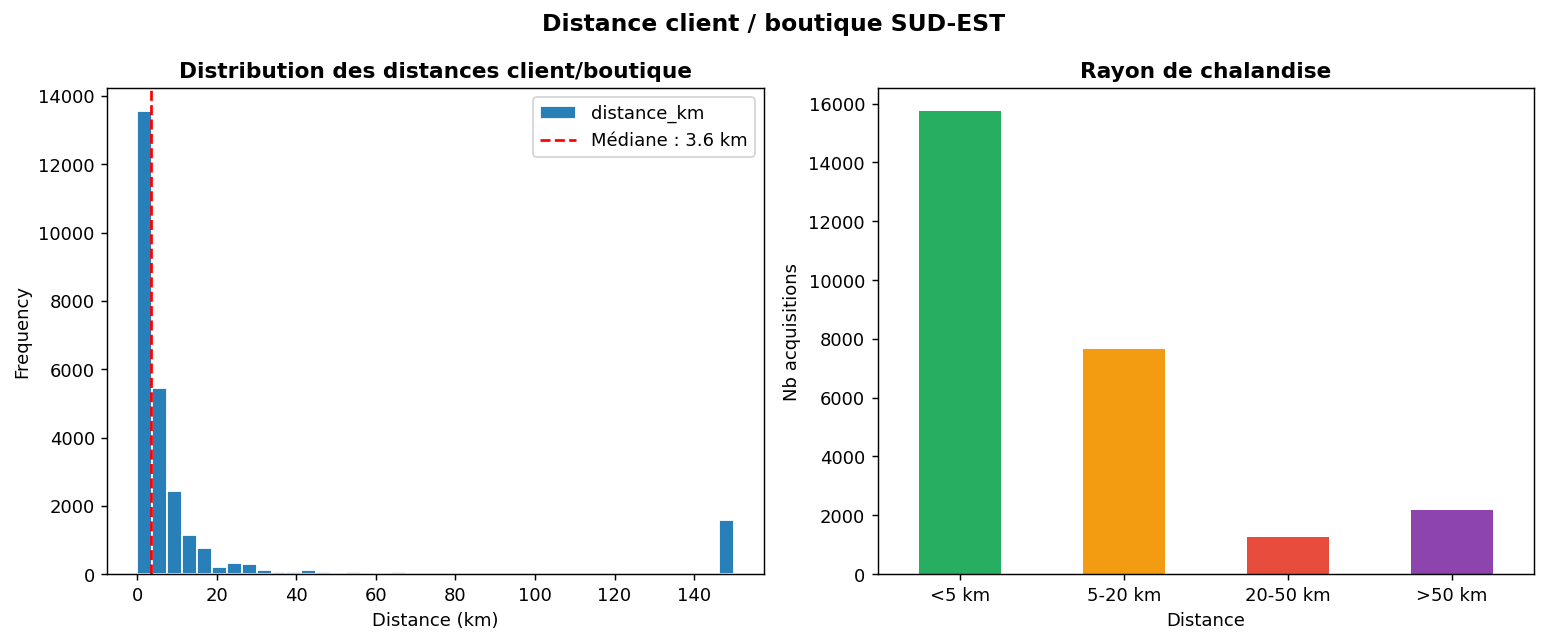

In [6]:
df['rayon_chalandise'] = pd.cut(
    df['distance_km'],
    bins=[0, 5, 20, 50, np.inf],
    labels=['<5 km', '5-20 km', '20-50 km', '>50 km']
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribution distance
df['distance_km'].dropna().clip(upper=150).plot(kind='hist', bins=40, ax=axes[0], color='#2980b9', edgecolor='white')
axes[0].axvline(df['distance_km'].median(), color='red', linestyle='--',
                label=f"Médiane : {df['distance_km'].median():.1f} km")
axes[0].set_title('Distribution des distances client/boutique', fontweight='bold')
axes[0].set_xlabel('Distance (km)')
axes[0].legend()

# Rayon chalandise
rayon_counts = df['rayon_chalandise'].value_counts().sort_index()
rayon_counts.plot(kind='bar', ax=axes[1], color=['#27ae60', '#f39c12', '#e74c3c', '#8e44ad'])
axes[1].set_title('Rayon de chalandise', fontweight='bold')
axes[1].set_xlabel('Distance')
axes[1].set_ylabel('Nb acquisitions')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Distance client / boutique SUD-EST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('5_distance.png', bbox_inches='tight')
plt.show()

## 5.5 Taux de croissance annuel (croissance_yoy)

In [7]:
df = df.drop(columns=['croissance_yoy'], errors='ignore')

years = sorted(df['PERIOD_YYYY'].unique())

if len(years) >= 2:
    yr_n1, yr_n = years[-2], years[-1]
    vol_pivot = df.groupby(['ORDER_SHOP_CD', 'PERIOD_YYYY']).size().unstack(fill_value=0)
    
    if yr_n1 in vol_pivot.columns and yr_n in vol_pivot.columns:
        vol_pivot['croissance_yoy'] = (
            (vol_pivot[yr_n] - vol_pivot[yr_n1]) / vol_pivot[yr_n1].replace(0, np.nan) * 100
        ).round(2)
        df = df.merge(
            vol_pivot[['croissance_yoy']].reset_index(),
            on='ORDER_SHOP_CD', how='left'
        )
        print(f"croissance_yoy calculée ({yr_n1} → {yr_n})")
        print(df['croissance_yoy'].describe().round(1))
    else:
        df['croissance_yoy'] = np.nan
else:
    df['croissance_yoy'] = np.nan
    print("1 seule année — croissance_yoy = NaN")

croissance_yoy calculée (2021 → 2022)
count    225547.0
mean         16.1
std          94.9
min        -100.0
25%          -8.2
50%          10.0
75%          24.6
max        4900.0
Name: croissance_yoy, dtype: float64


## 5.6 Part mobile / Part fixe par boutique

In [8]:
df = df.drop(columns=['part_mobile', 'part_fixe'], errors='ignore')

print("LINE_TYPE uniques :", df['LINE_TYPE'].unique())

# Compter par boutique et type
lt_pivot = df.groupby(['ORDER_SHOP_CD', 'LINE_TYPE']).size().unstack(fill_value=0)
lt_pivot['total'] = lt_pivot.sum(axis=1)

# Détecter mobile (T) et fixe/box (B, F, ou autre) selon les valeurs disponibles
mobile_cols = [c for c in lt_pivot.columns if c in ['T', 'M', 'MOBILE']]
fixe_cols   = [c for c in lt_pivot.columns if c in ['F', 'B', 'FIXE', 'BOX']]

if mobile_cols:
    lt_pivot['part_mobile'] = lt_pivot[mobile_cols].sum(axis=1) / lt_pivot['total']
else:
    lt_pivot['part_mobile'] = np.nan

if fixe_cols:
    lt_pivot['part_fixe'] = lt_pivot[fixe_cols].sum(axis=1) / lt_pivot['total']
else:
    lt_pivot['part_fixe'] = np.nan

df = df.merge(
    lt_pivot[['part_mobile', 'part_fixe']].reset_index(),
    on='ORDER_SHOP_CD', how='left'
)

print("\nStats part_mobile par boutique :")
if df['part_mobile'].notna().any():
    print(df.drop_duplicates('ORDER_SHOP_CD')['part_mobile'].describe().round(3))
else:
    print("(variable non applicable avec les types disponibles)")

LINE_TYPE uniques : <StringArray>
['T', 'I', 'M']
Length: 3, dtype: str

Stats part_mobile par boutique :
count    1068.000
mean        0.769
std         0.361
min         0.000
25%         0.762
50%         1.000
75%         1.000
max         1.000
Name: part_mobile, dtype: float64


## 5.7 Score de rentabilité (modèle simplifié)
> **Hypothèses ARPU** (source ARCEP) :  
> - Mobile (T) : 200 EUR/an/client  
> - Box/Fixe (B/F) : 350 EUR/an/client  
> - Autres : 200 EUR/an/client

In [9]:
df = df.drop(columns=['ca_ligne', 'ca_estime', 'marge_estimee', 'score_rentabilite', 'rentable'], errors='ignore')

ARPU = {'T': 200, 'B': 350, 'F': 350}
ARPU_DEFAULT = 200
COUT_CC = 85_000
COUT_CV = 65_000

df['ca_ligne'] = df['LINE_TYPE'].map(ARPU).fillna(ARPU_DEFAULT)

# Agréger par boutique
boutique_finance = df.groupby('ORDER_SHOP_CD').agg(
    ca_estime=('ca_ligne', 'sum'),
    emplacement=('Emplacement_PDV', 'first')
).reset_index()

boutique_finance['cout_fonctionnement'] = boutique_finance['emplacement'].map(
    {'CC': COUT_CC, 'CV': COUT_CV}
).fillna(COUT_CV)

boutique_finance['marge_estimee'] = boutique_finance['ca_estime'] - boutique_finance['cout_fonctionnement']
boutique_finance['score_rentabilite'] = (boutique_finance['ca_estime'] / boutique_finance['cout_fonctionnement']).round(2)
boutique_finance['rentable'] = boutique_finance['marge_estimee'] > 0

# Merge dans df principal
df = df.merge(
    boutique_finance[['ORDER_SHOP_CD', 'ca_estime', 'marge_estimee', 'score_rentabilite', 'rentable']],
    on='ORDER_SHOP_CD', how='left'
)

print(f"\nBoutiques rentables : {boutique_finance['rentable'].sum()} / {len(boutique_finance)}")
print(f"Marge estimée médiane par boutique : {boutique_finance['marge_estimee'].median():,.0f} EUR")
print("\nTop 5 boutiques par score de rentabilité :")
print(boutique_finance.nlargest(5, 'score_rentabilite')[['ORDER_SHOP_CD', 'ca_estime', 'marge_estimee', 'score_rentabilite']])


Boutiques rentables : 103 / 1068
Marge estimée médiane par boutique : -64,400 EUR

Top 5 boutiques par score de rentabilité :
     ORDER_SHOP_CD  ca_estime  marge_estimee  score_rentabilite
1044       SOSHOES  3955600.0      3890600.0              60.86
1024    PDV-MYSHOP  3067000.0      3002000.0              47.18
1004      ONEESHOP  2550400.0      2485400.0              39.24
1060        VADPCM  1748200.0      1683200.0              26.90
259     26200FK7-7   815000.0       750000.0              12.54


## 5.8 Sauvegarde du dataset enrichi

In [10]:
df.to_csv('base_enrichie_SUD_EST.csv', index=False)
print(f"base_enrichie_SUD_EST.csv sauvegardée : {len(df):,} lignes x {df.shape[1]} colonnes")

nouvelles_vars = ['age_client', 'tranche_age', 'annee', 'trimestre', 'distance_km',
                  'rayon_chalandise', 'croissance_yoy', 'part_mobile', 'part_fixe',
                  'ca_ligne', 'score_rentabilite']
print("\nNouvelles variables créées :")
for v in nouvelles_vars:
    ok = v in df.columns
    print(f"  {'✓' if ok else '✗'} {v}")

base_enrichie_SUD_EST.csv sauvegardée : 226,677 lignes x 34 colonnes

Nouvelles variables créées :
  ✓ age_client
  ✓ tranche_age
  ✓ annee
  ✓ trimestre
  ✓ distance_km
  ✓ rayon_chalandise
  ✓ croissance_yoy
  ✓ part_mobile
  ✓ part_fixe
  ✓ ca_ligne
  ✓ score_rentabilite


## 5.9 Visualisation des nouvelles variables

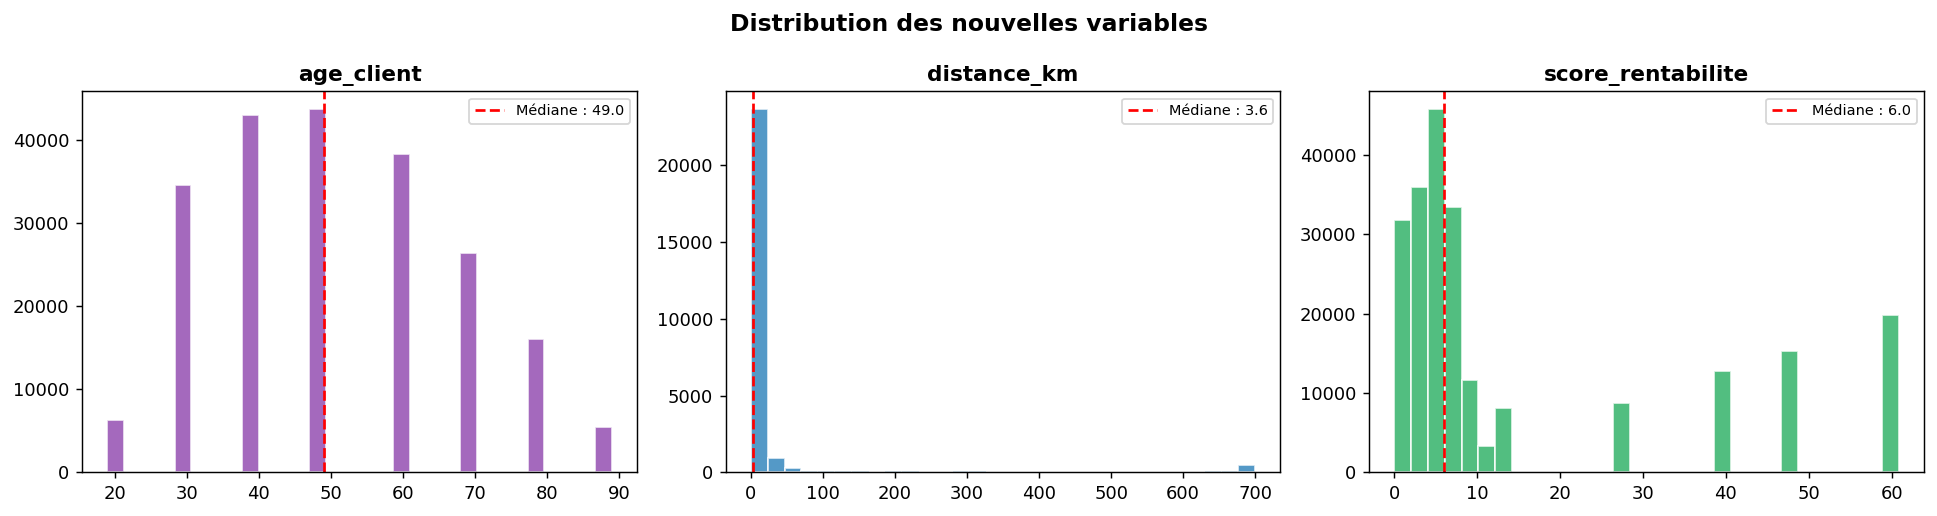

In [11]:
# Résumé statistique des nouvelles variables numériques
num_vars = ['age_client', 'distance_km', 'score_rentabilite']
num_vars_ok = [v for v in num_vars if v in df.columns]

fig, axes = plt.subplots(1, len(num_vars_ok), figsize=(5*len(num_vars_ok), 4))
if len(num_vars_ok) == 1:
    axes = [axes]

colors = ['#8e44ad', '#2980b9', '#27ae60']
for ax, var, color in zip(axes, num_vars_ok, colors):
    data = df[var].dropna().clip(
        upper=df[var].quantile(0.99)
    )
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Médiane : {data.median():.1f}')
    ax.set_title(f'{var}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des nouvelles variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('5_nouvelles_variables.png', bbox_inches='tight')
plt.show()

## Conclusion Etape 5

| Variable créée | Méthode | Utilité |
|---|---|---|
| `age_client` | Milieu de décennie naissance | Segmentation démographique |
| `tranche_age` | Cut en 4 tranches | Visualisations lisibles |
| `annee` / `trimestre` | Extraction PERIOD | Analyses temporelles |
| `distance_km` | Haversine lat/lon | Rayon de chalandise |
| `rayon_chalandise` | Bucketing distance | Segmentation spatiale |
| `croissance_yoy` | (N - N-1) / N-1 | Tendance boutique |
| `part_mobile` / `part_fixe` | Ratio par boutique | Spécialisation |
| `score_rentabilite` | CA estimé / Coût | Modèle business |

**→ Prochaine étape : Analyse métier (Etape 6)**